<a href="https://colab.research.google.com/github/stephentangzizhong/Neuroinformatics-Workshop-Code/blob/main/8_Neural_fields.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from scipy.special import i0
import numpy as np

In [ ]:
def activity(stims, means, sharpnesses, rates=5):
  '''
  Simulate activity of a population of neurons to a set of angular stimuli,
  according to a Poisson whose mean is von Mises tuning

  Inputs
  ------

  stims: angles of all the stimuli are stims (in radians, size nStims)

  means: mean angular tuning of each neuron (in radians, size nNeurons)

  sharpnesses: tuning sharpness of each neuron (size nNeurons)

  rates: RMS of the von Mises rate of each neuron (size nNeurons)
          (note the actual RMS will be larger due to Poisson variability)

  Outputs
  -------

  firing: integer array, size nStims x nNeurons
  '''

  # get arrays the right shape for broadcasting
  stims = np.atleast_1d(stims)[:,None]
  means = np.atleast_1d(means)[None,:]
  sharpnesses = np.atleast_1d(sharpnesses)[None,:]
  rates = np.atleast_1d(rates)[None,:]

  pred_rate = np.exp(np.cos(stims-means)*sharpnesses)*rates \
  /np.sqrt(i0(2*sharpnesses))
  #  /i0(sharpnesses)

  firing = np.random.poisson(pred_rate)
  return firing

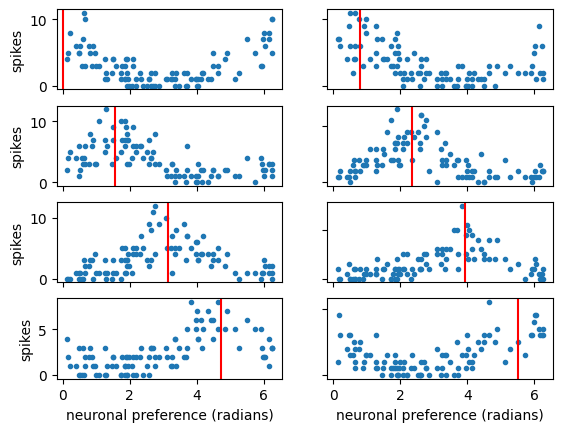

In [ ]:
# simulate some cells with random tuning preference and uniform tuning sharpness

nNeurons = 100
prefs = np.random.rand(nNeurons)*2*np.pi

nStims = 8
stims = np.linspace(0,2*np.pi, nStims+1)[:-1]

a=activity(stims,prefs,1,4)

for i in np.arange(nStims):
  plt.subplot(4,2,i+1)
  plt.plot(prefs, a[i,:], '.')
  plt.xlabel('neuronal preference (radians)')
  plt.ylabel('spikes')
  plt.axvline(stims[i], color='r')

  plt.gca().label_outer()


Text(0, 0.5, 'Stim 2 (radians)')

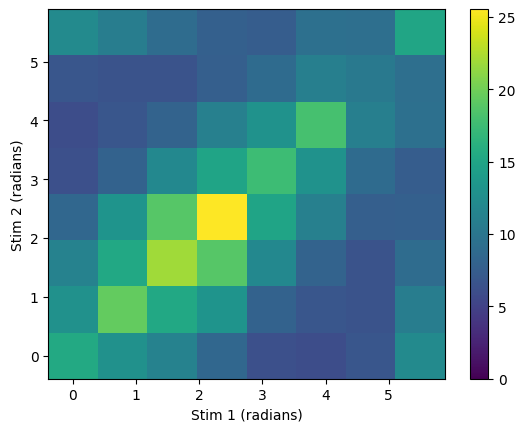

In [ ]:
# now let's compute the kernel matrix, which measures the similarity of population responses to each pair of stimuli

K = a@a.T / nNeurons
plt.pcolormesh(stims, stims, K, vmin=0)
plt.colorbar()
plt.xlabel('Stim 1 (radians)')
plt.ylabel('Stim 2 (radians)')

**QUESTION**
Why does it look like this?  What value would you expect to see on the diagonal?

On the diagonal, similarities are calculated between the population response of one stimulus and that of itself. Thus, the similarity on the diagonal will always be higher than other pixels. Pixels near the diagonal are brighter because similar stimuli (in this case, stimuli are angles on a continuous scale) often induce similar population response.  

The values are supposed to be the expected value of **a**^2. But because the number of neurons is not large enough, they may only have preference for a few stimuli. As the number of neurons increases, the values on the diagonal should be consistent.

**EXERCISE**
Compute the kernel matrix for the same stimuli and different numbers of neurons, in powers of 2: 2^1 up to 2^16, and store the result in a 3d array. plot them all as pseudocolor maps

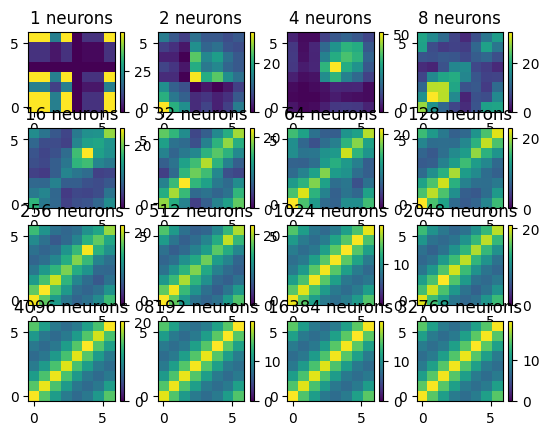

In [ ]:
# should look like this:
kernel_matrix = []

for i in range(16):
  nNeurons = 2**i
  prefs = np.random.rand(nNeurons)*2*np.pi

  a=activity(stims,prefs,1,4)

  K = a@a.T / nNeurons

  kernel_matrix.append(K)

  plt.subplot(4,4,i+1)
  plt.pcolormesh(stims, stims, K, vmin=0)
  plt.colorbar()
  plt.title(str(2**i) + ' neurons')

plt.show()



In [ ]:
print(kernel_matrix)

[array([[49., 49., 21., 49.,  0.,  7.,  7., 49.],
       [49., 49., 21., 49.,  0.,  7.,  7., 49.],
       [21., 21.,  9., 21.,  0.,  3.,  3., 21.],
       [49., 49., 21., 49.,  0.,  7.,  7., 49.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 7.,  7.,  3.,  7.,  0.,  1.,  1.,  7.],
       [ 7.,  7.,  3.,  7.,  0.,  1.,  1.,  7.],
       [49., 49., 21., 49.,  0.,  7.,  7., 49.]]), array([[32.5, 20.5, 16. ,  4. ,  6.5,  3. ,  6. , 13.5],
       [20.5, 13. , 10. ,  4. ,  5. ,  3. ,  4.5,  9. ],
       [16. , 10. ,  8. ,  0. ,  2. ,  0. ,  2. ,  6. ],
       [ 4. ,  4. ,  0. , 32. , 20. , 24. , 16. , 12. ],
       [ 6.5,  5. ,  2. , 20. , 13. , 15. , 10.5,  9. ],
       [ 3. ,  3. ,  0. , 24. , 15. , 18. , 12. ,  9. ],
       [ 6. ,  4.5,  2. , 16. , 10.5, 12. ,  8.5,  7.5],
       [13.5,  9. ,  6. , 12. ,  9. ,  9. ,  7.5,  9. ]]), array([[ 3.  ,  1.  ,  1.5 ,  4.5 ,  8.25,  8.75,  8.25,  5.  ],
       [ 1.  ,  0.5 ,  0.5 ,  2.  ,  4.  ,  2.25,  2.  ,  1.5 ],
       [ 1.5 ,  0

**EXERCISE**
Now plot the values in the first row of the kernel matrix as a function of neuron count, using a log x-axis

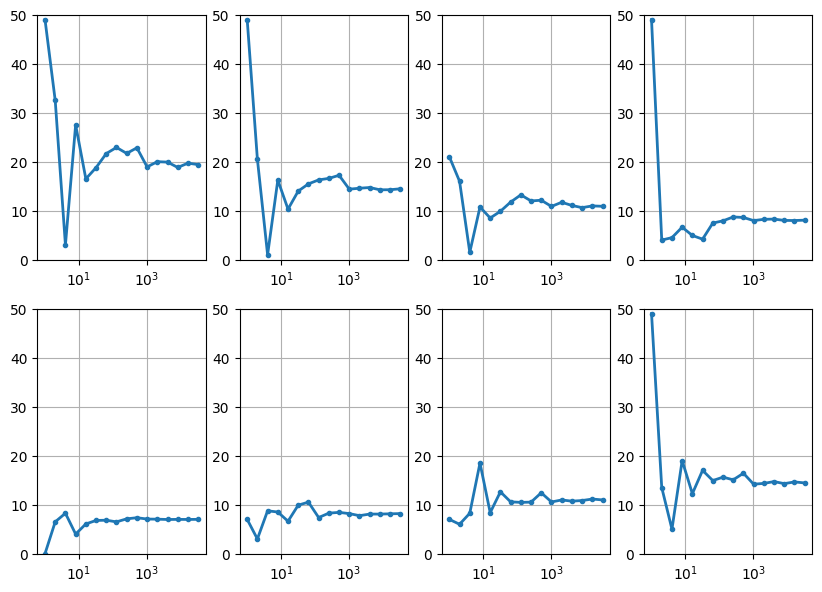

In [ ]:
x = []
y = []

for i in range(16):
  x.append(2**i)

fig, ax = plt.subplots(2, 4, figsize=(10,7))

for k in range(nStims):

  for j in range(16):
    y.append(kernel_matrix[j][0][k])

  ax[k//4,k%4].plot(x, y, marker='o', markersize=3, linestyle='-', linewidth=2)
  ax[k//4,k%4].set_xscale('log')
  ax[k//4,k%4].grid()
  ax[k//4,k%4].set_ylim([0,50])
  y=[]

plt.show()

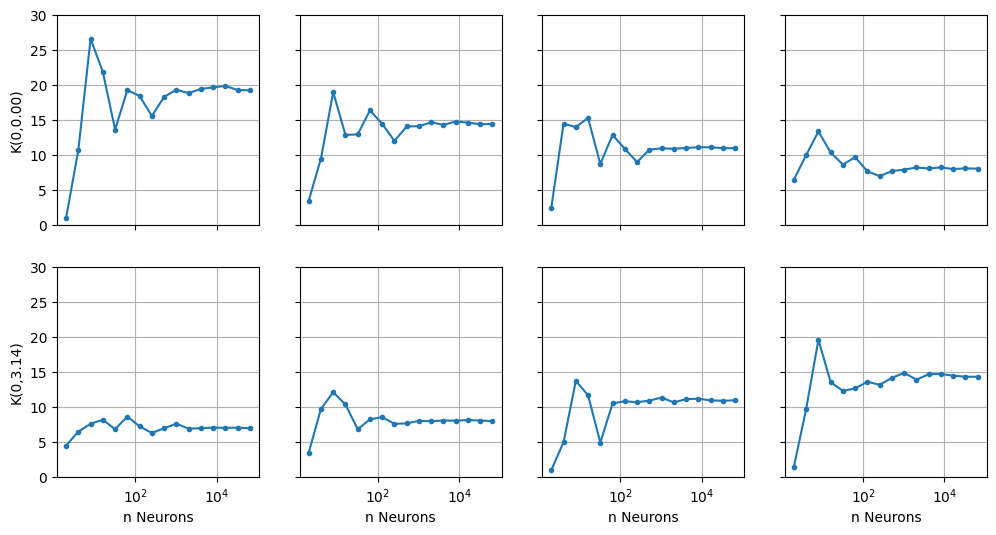

In [ ]:
# MODEL ANSWER
plt.figure(figsize=(12,6))
for i in range(len(stims)):
  plt.subplot(2,4,i+1)
  plt.semilogx(nCounts, kernels[:,0,i], '.-')
  plt.ylabel(f'K(0,%.2f)'%stims[i])
  plt.xlabel('n Neurons')
  plt.ylim([0,30])
  plt.grid()
  plt.gca().label_outer()

**QUESTION**

Interpret this result

As number of neurons increases, the kernel matrices become more stable.